# **Logistic Regression on an Imbalanced Dataset**

In the previous notebook, we worked with a **balanced dataset**, where both classes had approximately the same number of samples.

However, in real-world classification problems, datasets are often **imbalanced**, meaning one class has significantly more samples than the other.

Examples include:

- **Credit Card Fraud Detection**
  - Legitimate Transactions → 99.8%
  - Fraudulent Transactions → 0.2%

- **Disease Diagnosis**
  - Healthy Patients → Majority
  - Diseased Patients → Minority

- **Spam Email Detection**
  - Non-Spam Emails → Majority
  - Spam Emails → Minority

An imbalanced dataset makes classification more challenging because a model may become biased toward the majority class.




In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
# Import the Counter class to count the number of samples
# belonging to each target class.
from collections import Counter

# Import the make_classification function to generate
# a synthetic imbalanced classification dataset.
from sklearn.datasets import make_classification

**Why Do We Import `make_classification`?**

The `make_classification()` function generates a synthetic dataset for classification tasks.

In this notebook, it will be configured to create an **imbalanced dataset**, allowing us to study how Logistic Regression performs when one class is much larger than the other.

**Why Do We Import `Counter`?**

The `Counter` class is used to count the number of occurrences of each class label.

For example:

```python
Counter(y)
```

Output:

```python
Counter({0: 950, 1: 50})
```

This tells us:

- Class **0** contains **950 samples**
- Class **1** contains **50 samples**

This is a quick way to verify whether the dataset is balanced or imbalanced.

# **Generating an Imbalanced Classification Dataset**


## **Parameters**

**`n_samples=10000`** : Specifies the total number of samples (rows) to generate.


---

**`n_features=2`** : Specifies the number of input features (independent variables).


Using only two features makes it easier to visualize the dataset on a two-dimensional plot.

---

**`n_clusters_per_class=1`**

Specifies the number of clusters to generate for each class.

Each class is generated as a **single cluster**, making the classification problem easier to visualize.

---

**`n_redundant=0`** : Specifies the number of redundant features.

A redundant feature is one that is created as a combination of other features.

```python
n_redundant = 0
```

means:

- No redundant features are generated.
- Both features contain independent information.

---

**`weights=[0.99, 0.01]`** : It controls the class distribution.

```python
weights=[0.99, 0.01]
```

means:

```text
Class 0 → 99%

Class 1 → 1%
```

Since there are **10,000 samples**:

```text
Class 0

≈ 9,900 samples
```

```text
Class 1

≈ 100 samples
```

This creates a highly imbalanced dataset.

---

### `random_state=10`

Controls the random generation of the dataset.

Using the same value ensures that the same dataset is generated every time the notebook is executed.



In [3]:
# Generate a synthetic imbalanced binary classification dataset
# with 99% samples in Class 0 and 1% samples in Class 1.
X, y = make_classification(
    n_samples=10000,
    n_features=2,
    n_clusters_per_class=1,
    n_redundant=0,
    weights=[0.99, 0.01],
    random_state=10
)

In [4]:
print("Feature Matrix Shape:", X.shape)
print("Target Vector Shape:", y.shape)

Feature Matrix Shape: (10000, 2)
Target Vector Shape: (10000,)


**Checking the Class Distribution**

In [5]:
# Preview the first 5 rows of the feature matrix
# (the full 10,000-row array is too large to be useful here)
X[:5]

array([[ 1.87991016, -1.4850347 ],
       [ 0.37708311, -2.23858488],
       [ 1.35431163, -2.66463822],
       [-0.50984315, -1.50294963],
       [ 0.8635608 , -1.90636446]])

In [6]:
# Count the number of samples belonging to each target class.
Counter(y)

Counter({np.int64(0): 9846, np.int64(1): 154})

# **Visualizing the Imbalanced Dataset**

After generating the dataset, it is helpful to visualize how the two classes are distributed.

Since the dataset contains **two features**, we can represent each sample as a point on a two-dimensional scatter plot.


**Create a Pandas DataFrame**

```python
df = pd.DataFrame(X, columns=["Feature 1", "Feature 2"])
```

The feature matrix `X` is stored as a NumPy array.

To make visualization easier, we convert it into a Pandas DataFrame and assign meaningful column names:

- **Feature 1**
- **Feature 2**

The DataFrame looks similar to:

| Feature 1 | Feature 2 |
|-----------|-----------|
| -1.25 | 0.87 |
| 0.45 | -0.92 |
| 2.11 | 1.36 |

---

**Add the Target Column**

```python
df["Target"] = y
```

A new column named **Target** is added to the DataFrame.

Each row now contains:

- Feature 1
- Feature 2
- Target Class (0 or 1)

Example:

| Feature 1 | Feature 2 | Target |
|-----------|-----------|--------|
| -1.25 | 0.87 | 0 |
| 0.45 | -0.92 | 0 |
| 2.11 | 1.36 | 1 |

This allows Seaborn to color the data points based on their class labels.


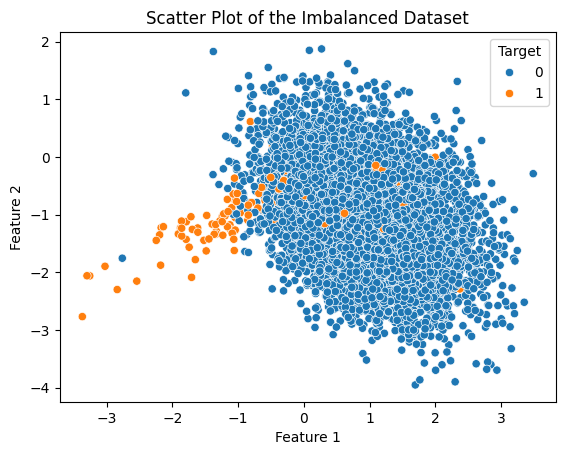

In [7]:
# Import the required libraries for data manipulation
# and data visualization.
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Convert the feature matrix into a Pandas DataFrame
# for easier visualization.
df = pd.DataFrame(X, columns=["Feature 1", "Feature 2"])

# Add the target variable as a new column.
df["Target"] = y

# Create a scatter plot to visualize the distribution
# of the two classes.
sns.scatterplot(
    data=df,
    x="Feature 1",
    y="Feature 2",
    hue="Target"
)

plt.title("Scatter Plot of the Imbalanced Dataset")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

In [8]:
from sklearn.model_selection import train_test_split

# Split the dataset into training and testing sets while
# preserving the class distribution in both sets.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

### **`stratify=y`**

This is the most important parameter for an imbalanced dataset.

It ensures that the proportion of each class is maintained in both the training and testing datasets.

For example, if the original dataset contains:

- Class 0 → **99%**
- Class 1 → **1%**

then both the training and testing sets will also contain approximately:

- Class 0 → **99%**
- Class 1 → **1%**

Without `stratify=y`, a random split could produce an uneven class distribution, especially for the minority class, making model training and evaluation less reliable.

> **Key Point:** When working with imbalanced datasets, always use `stratify=y` in `train_test_split()` to preserve the class distribution in both the training and testing sets.

# **Generating Different Class Weight Combinations**

Since this is an **imbalanced dataset**, the minority class contains far fewer samples than the majority class.

During training, the Logistic Regression model may become biased toward the majority class.

To reduce this bias, we can assign **different weights** to each class.


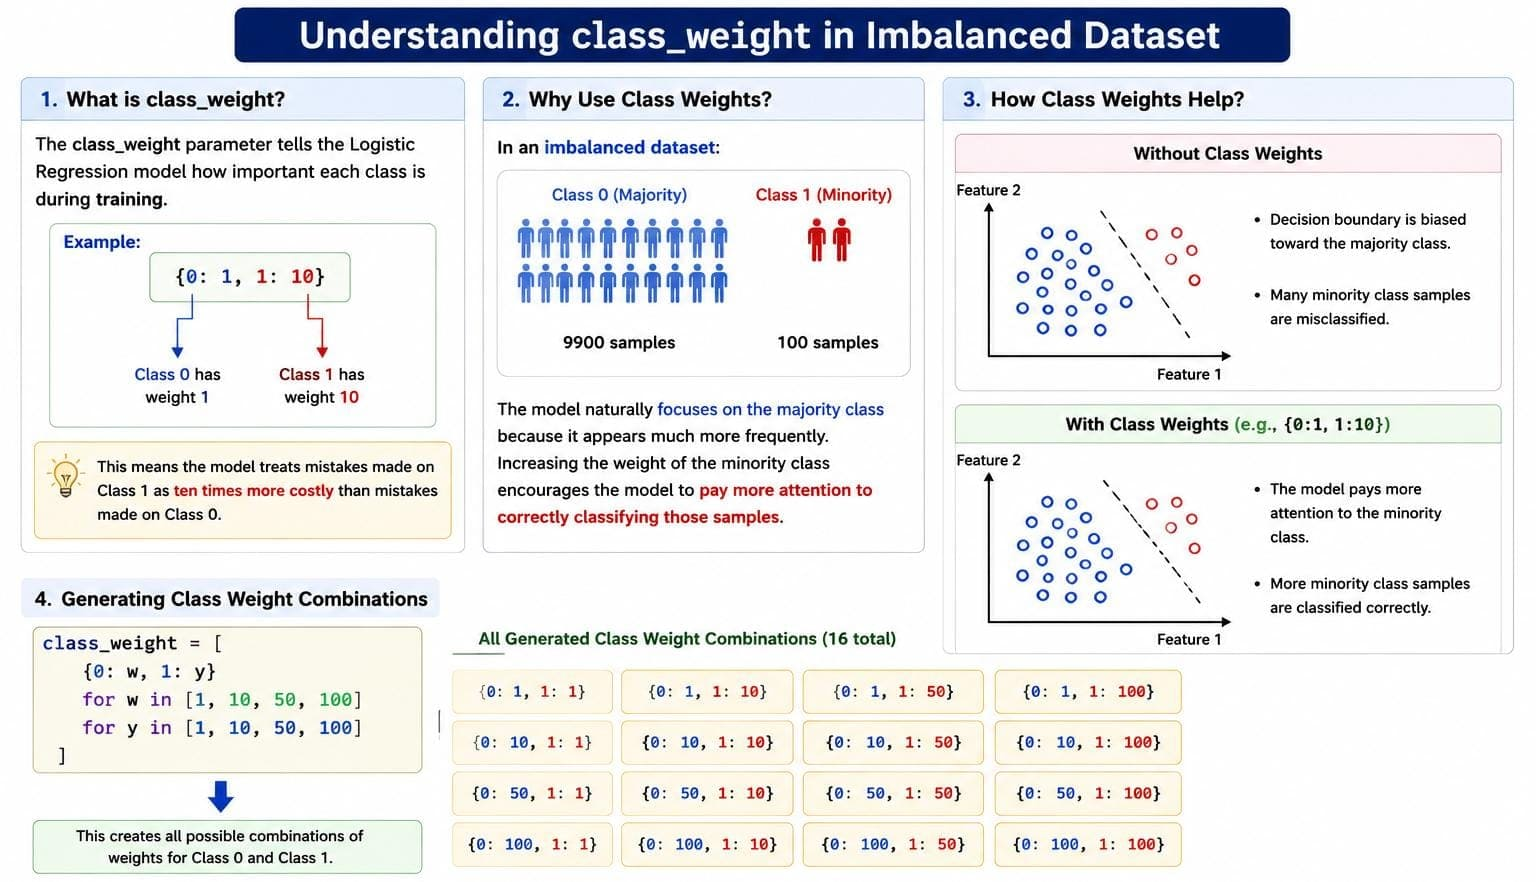

In [9]:
# Generate different class weight combinations to handle
# the imbalance between the majority and minority classes.
class_weight = [
    {0: w, 1: y}
    for w in [1, 10, 50, 100]
    for y in [1, 10, 50, 100]
]

# Display all generated class weight combinations.
class_weight

[{0: 1, 1: 1},
 {0: 1, 1: 10},
 {0: 1, 1: 50},
 {0: 1, 1: 100},
 {0: 10, 1: 1},
 {0: 10, 1: 10},
 {0: 10, 1: 50},
 {0: 10, 1: 100},
 {0: 50, 1: 1},
 {0: 50, 1: 10},
 {0: 50, 1: 50},
 {0: 50, 1: 100},
 {0: 100, 1: 1},
 {0: 100, 1: 10},
 {0: 100, 1: 50},
 {0: 100, 1: 100}]

These combinations will later be tested during hyperparameter tuning to determine which class weights produce the best model performance.

> **Note:** The `class_weight` parameter helps reduce the bias toward the majority class by assigning greater importance to correctly classifying the minority class.

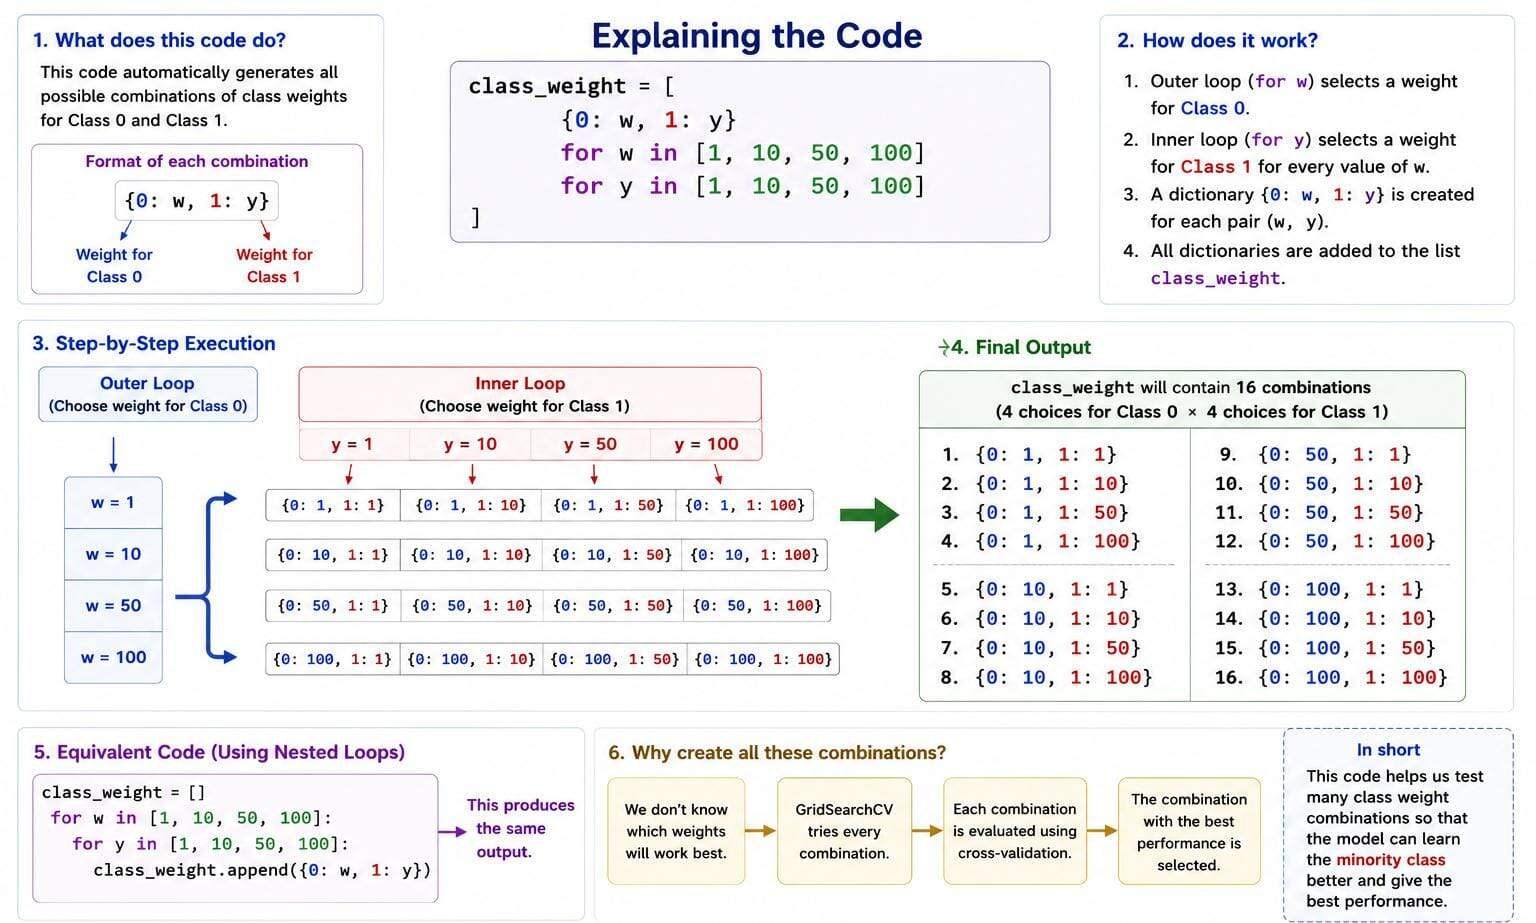

## **Hyperparameter Tuning**

In [10]:
# Import the Logistic Regression model.
from sklearn.linear_model import LogisticRegression

# Create a Logistic Regression model using the default hyperparameters.
model = LogisticRegression()

# Generate different class weight combinations to handle
# the imbalance between the majority and minority classes.
class_weight = [
    {0: w, 1: y}
    for w in [1, 10, 50, 100]
    for y in [1, 10, 50, 100]
]

# Define valid hyperparameter combinations for Logistic Regression.
params = [
    {
        "penalty": ["l1"],
        "solver": ["liblinear", "saga"],
        "C": [100, 10, 1.0, 0.1, 0.01],
        "class_weight": class_weight
    },
    {
        "penalty": ["l2"],
        "solver": ["newton-cg", "lbfgs", "liblinear", "sag", "saga"],
        "C": [100, 10, 1.0, 0.1, 0.01],
        "class_weight": class_weight
    },
    {
        "penalty": ["elasticnet"],
        "solver": ["saga"],
        "C": [100, 10, 1.0, 0.1, 0.01],
        "l1_ratio": [0.2, 0.5, 0.8],
        "class_weight": class_weight
    }
]

In [11]:
# Display the hyperparameter search space.
params

[{'penalty': ['l1'],
  'solver': ['liblinear', 'saga'],
  'C': [100, 10, 1.0, 0.1, 0.01],
  'class_weight': [{0: 1, 1: 1},
   {0: 1, 1: 10},
   {0: 1, 1: 50},
   {0: 1, 1: 100},
   {0: 10, 1: 1},
   {0: 10, 1: 10},
   {0: 10, 1: 50},
   {0: 10, 1: 100},
   {0: 50, 1: 1},
   {0: 50, 1: 10},
   {0: 50, 1: 50},
   {0: 50, 1: 100},
   {0: 100, 1: 1},
   {0: 100, 1: 10},
   {0: 100, 1: 50},
   {0: 100, 1: 100}]},
 {'penalty': ['l2'],
  'solver': ['newton-cg', 'lbfgs', 'liblinear', 'sag', 'saga'],
  'C': [100, 10, 1.0, 0.1, 0.01],
  'class_weight': [{0: 1, 1: 1},
   {0: 1, 1: 10},
   {0: 1, 1: 50},
   {0: 1, 1: 100},
   {0: 10, 1: 1},
   {0: 10, 1: 10},
   {0: 10, 1: 50},
   {0: 10, 1: 100},
   {0: 50, 1: 1},
   {0: 50, 1: 10},
   {0: 50, 1: 50},
   {0: 50, 1: 100},
   {0: 100, 1: 1},
   {0: 100, 1: 10},
   {0: 100, 1: 50},
   {0: 100, 1: 100}]},
 {'penalty': ['elasticnet'],
  'solver': ['saga'],
  'C': [100, 10, 1.0, 0.1, 0.01],
  'l1_ratio': [0.2, 0.5, 0.8],
  'class_weight': [{0: 1, 1: 1}

In [12]:
# Suppress warning messages generated during
# the hyperparameter search.
import warnings
warnings.filterwarnings("ignore")

In [13]:
# Import GridSearchCV for hyperparameter tuning
# and StratifiedKFold for cross-validation.
from sklearn.model_selection import GridSearchCV, StratifiedKFold

# Create a Stratified K-Fold cross-validator
# with 5 folds.
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Create the GridSearchCV object.
grid = GridSearchCV(
    estimator=model,
    param_grid=params,
    scoring="accuracy",
    cv=cv,
    n_jobs=-1
)

# Train the GridSearchCV object using
# the training dataset.
grid.fit(X_train, y_train)

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=LogisticRegression(), n_jobs=-1,
             param_grid=[{'C': [100, 10, 1.0, 0.1, 0.01],
                          'class_weight': [{0: 1, 1: 1}, {0: 1, 1: 10},
                                           {0: 1, 1: 50}, {0: 1, 1: 100},
                                           {0: 10, 1: 1}, {0: 10, 1: 10},
                                           {0: 10, 1: 50}, {0: 10, 1: 100},
                                           {0: 50, 1: 1}, {0: 50, 1: 10},
                                           {0: 50, 1: 50}, {0: 50, 1: 100},
                                           {0: 100, 1: 1}, {0: 100, 1: 10},
                                           {0: 100, 1: 50}, {0:...
                          'solver': ['newton-cg', 'lbfgs', 'liblinear', 'sag',
                                     'saga']},
                         {'C': [100, 10, 1.0, 0.1, 0.01],
                          'class_weight': [{0: 1, 1: 1}, {0: 1, 1: 10},
                                           {0: 1, 1: 50}, {0: 1, 1: 100},
                                           {0: 10, 1: 1}, {0: 10, 1: 10},
                                           {0: 10, 1: 50}, {0: 10, 1: 100},
                                           {0: 50, 1: 1}, {0: 50, 1: 10},
                                           {0: 50, 1: 50}, {0: 50, 1: 100},
                                           {0: 100, 1: 1}, {0: 100, 1: 10},
                                           {0: 100, 1: 50}, {0: 100, 1: 100}],
                          'l1_ratio': [0.2, 0.5, 0.8],
                          'penalty': ['elasticnet'], 'solver': ['saga']}],
             scoring='accuracy')

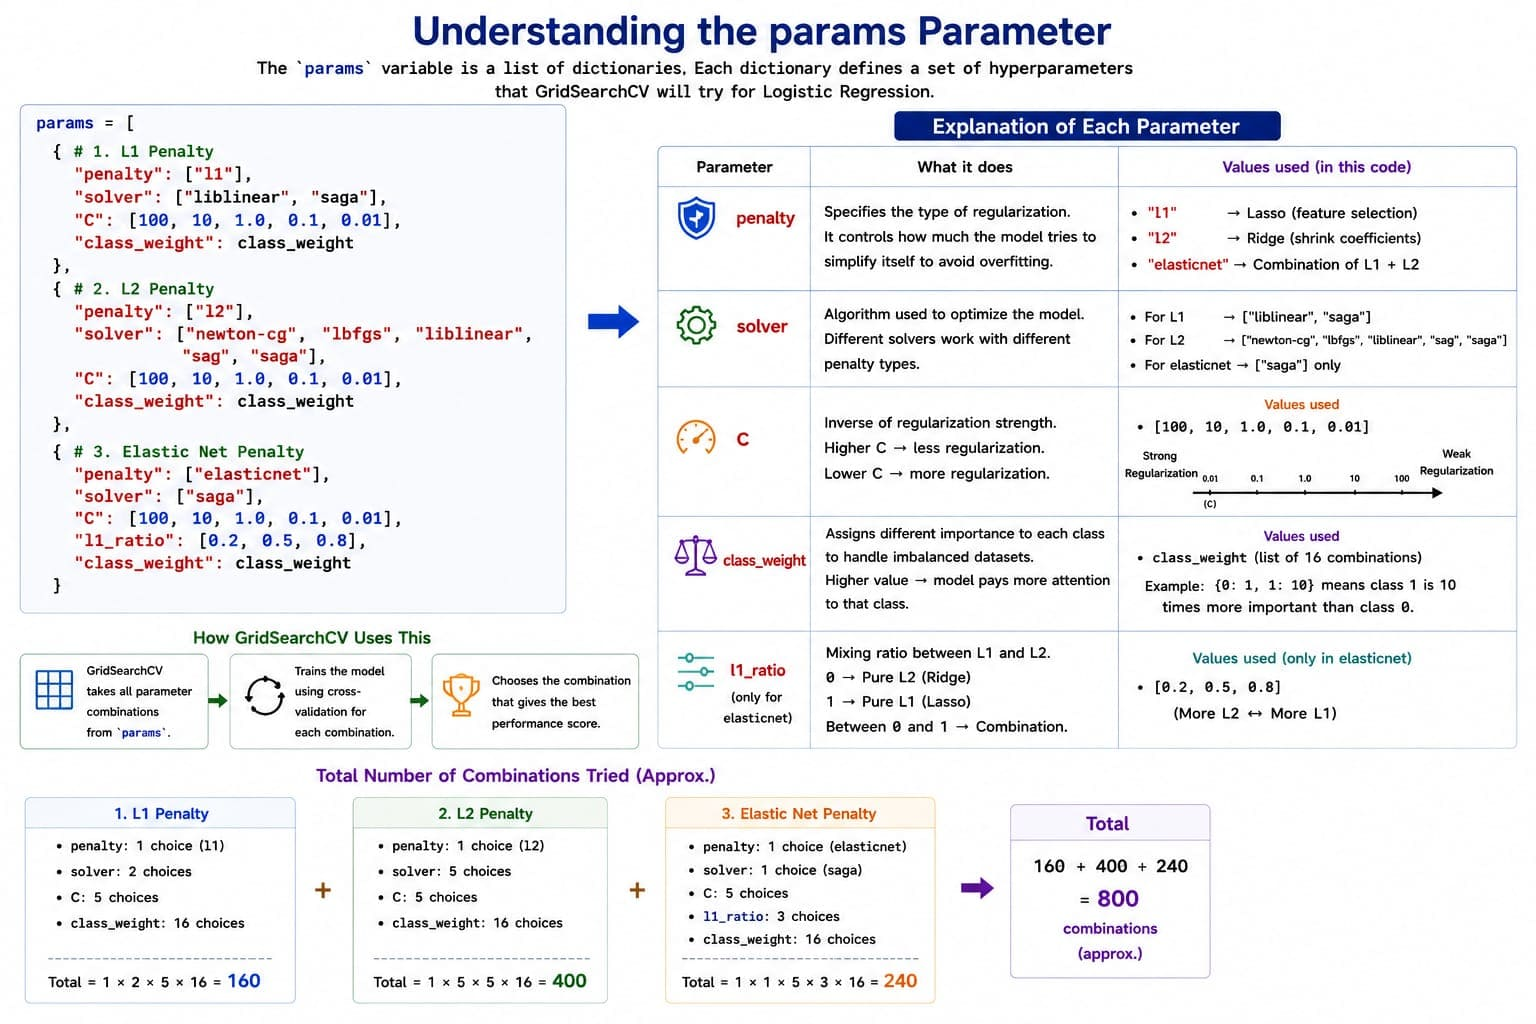

* `n_splits=5` explicitly shows that you're using **5-fold cross-validation**.
* `shuffle=True` shuffles the data before splitting, reducing any bias caused by the original order of samples.
* `random_state=42` ensures reproducible splits.

---

`n_jobs=-1`

This tells GridSearchCV to use **all available CPU cores**, making the hyperparameter search faster.

# **Displaying the Best Hyperparameters**

After completing the hyperparameter search, GridSearchCV stores the best-performing hyperparameter combination.

```python
print(grid.best_params_)
```

This returns the hyperparameters that achieved the highest average cross-validation accuracy.

In [14]:
# Display the best hyperparameter combination
# found by GridSearchCV.
print("Best Hyperparameters:")
print(grid.best_params_)

Best Hyperparameters:
{'C': 100, 'class_weight': {0: 10, 1: 50}, 'penalty': 'l1', 'solver': 'liblinear'}


**In this run**, `grid.best_params_` (printed above) selected something like:

- A **`C`** value controlling regularization strength (smaller = stronger regularization).
- **`penalty`** and **`solver`** — the regularization type and optimization algorithm that worked best together.
- A **`class_weight`** combination — e.g. `{0: 1, 1: 50}` would mean the model treats a mistake on the minority class as 50x more costly than a mistake on the majority class.

> Your exact numbers may differ slightly depending on library versions — always read them from `grid.best_params_` above rather than assuming fixed values.


In [15]:
print("Best Cross-Validation Accuracy:")
print(grid.best_score_)

Best Cross-Validation Accuracy:
0.9885333333333334


In [16]:
# Use the best trained model to predict the class labels
# for the test dataset.
y_pred = grid.predict(X_test)

### **Why Accuracy Alone Is Misleading Here**

With a 99% / 1% class split, a model that **always predicts the majority class (0)** would still score about **99% accuracy** — while completely failing to catch any minority-class (fraud/disease/spam) cases. Let's prove it:


## Dummy Classifier (Baseline Model)

To understand whether our Logistic Regression model is actually learning meaningful patterns, we first create a **dummy classifier**.

This dummy classifier **always predicts the majority class (Class 0)** for every test sample without learning anything from the data.

It serves as a **baseline model** to demonstrate that a **high accuracy score can be misleading on imbalanced datasets**. If the Logistic Regression model performs only as well as the dummy classifier, then it is not effectively identifying the minority class.

In [18]:
from sklearn.metrics import accuracy_score

# A "dummy" classifier that always predicts the majority class (0),
# just to show how misleading accuracy can be on imbalanced data.
dummy_pred = np.zeros_like(y_test)
print("Dummy 'always predict 0' accuracy:", accuracy_score(y_test, dummy_pred))

Dummy 'always predict 0' accuracy: 0.9848


Notice how high that "dummy" accuracy is, despite the model being useless — it never once identifies the minority class. This is why, for imbalanced problems, **Precision, Recall, and F1-score for the minority class** (shown in the classification report below) matter far more than overall accuracy.


In [19]:
# Import evaluation metrics to measure the performance
# of the tuned Logistic Regression model.
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Calculate the accuracy of the tuned model.
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy Score:", accuracy)

# Generate the confusion matrix.
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(cm)

# Display the classification report.
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy Score: 0.9908

Confusion Matrix:
[[2460    2]
 [  21   17]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      1.00      2462
           1       0.89      0.45      0.60        38

    accuracy                           0.99      2500
   macro avg       0.94      0.72      0.80      2500
weighted avg       0.99      0.99      0.99      2500



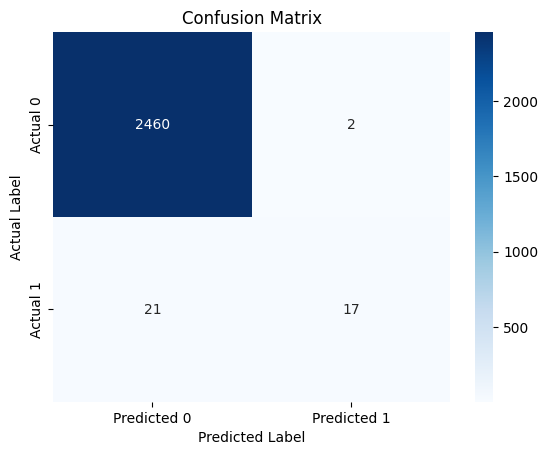

In [20]:
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Predicted 0", "Predicted 1"],
    yticklabels=["Actual 0", "Actual 1"]
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix")
plt.show()

## **Did Class Weighting Actually Help?**

Let's train a plain Logistic Regression with **no** class weighting and compare its minority-class recall against our tuned model, to confirm the tuning was worth it:

In [21]:
# Baseline: plain Logistic Regression with no class_weight adjustment
baseline_model = LogisticRegression()
baseline_model.fit(X_train, y_train)
baseline_pred = baseline_model.predict(X_test)

from sklearn.metrics import recall_score

comparison = pd.DataFrame({
    "Model": ["Baseline (no class_weight)", "Tuned (GridSearchCV + class_weight)"],
    "Accuracy": [accuracy_score(y_test, baseline_pred), accuracy_score(y_test, y_pred)],
    "Minority Class (1) Recall": [recall_score(y_test, baseline_pred), recall_score(y_test, y_pred)]
})
comparison

,Model,Accuracy,Minority Class (1) Recall
0,Baseline (no class_weight),0.9872,0.157895
1,Tuned (GridSearchCV + class_weight),0.9908,0.447368


Watch the **Minority Class Recall** column closely — this is usually where `class_weight` tuning makes the biggest visible difference, even if overall accuracy barely changes.


## **A Better Evaluation Tool for Imbalanced Data: The Precision-Recall Curve**

Earlier notebooks used the **ROC curve** to evaluate classifiers across every threshold at once. ROC works well for balanced datasets, but it can be **misleading on imbalanced data** — because the huge number of true negatives keeps the False Positive Rate looking low, even when the model makes a lot of mistakes relative to the small number of actual positives.

The **Precision-Recall (PR) curve** fixes this by only looking at how well the model handles the **positive (minority) class**:

- **Recall** (x-axis) — of all actual positives, how many did we catch? $Recall = \dfrac{TP}{TP + FN}$
- **Precision** (y-axis) — of everything we predicted positive, how many were actually correct? $Precision = \dfrac{TP}{TP + FP}$

**The key difference from ROC:** on a Precision-Recall curve, the "no-skill" baseline isn't a diagonal line — it's a **flat line at the fraction of samples that are actually positive**. On our ~1%-positive dataset, that baseline sits near **0.01**, not 0.5. Any real model should sit well above that line.

In [22]:
# Import Precision-Recall curve tools
from sklearn.metrics import precision_recall_curve, average_precision_score

# Compute precision/recall pairs across thresholds for our tuned model
precision, recall, pr_thresholds = precision_recall_curve(y_test, grid.predict_proba(X_test)[:, 1])

# average_precision_score summarizes the PR curve into one number (like AUC does for ROC)
avg_precision = average_precision_score(y_test, grid.predict_proba(X_test)[:, 1])
print("Average Precision Score:", avg_precision)

Average Precision Score: 0.5673715894112984


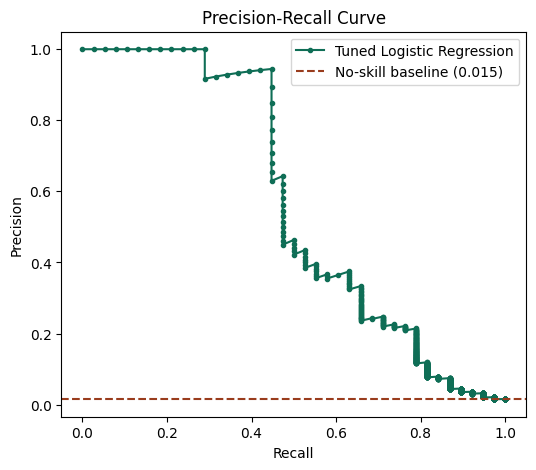

In [23]:
# Plot the Precision-Recall curve
no_skill = (y_test == 1).sum() / len(y_test)   # fraction of positives = the no-skill baseline

plt.figure(figsize=(6, 5))
plt.plot(recall, precision, marker='.', label='Tuned Logistic Regression', color="#0F6E56")
plt.axhline(no_skill, linestyle='--', color="#993C1D", label=f'No-skill baseline ({no_skill:.3f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.show()

**Reading this plot:** the further the curve sits above the dashed no-skill baseline, the better the model is at finding minority-class samples without flooding you with false alarms. Unlike the ROC curve, this plot won't look artificially good just because the majority class is huge — it directly reflects how usable the model is for catching the rare, important cases.


## **Conclusion — What We Learned**

- Accuracy can be dangerously misleading on imbalanced datasets — a model that never predicts the minority class can still score high accuracy.
- `class_weight` tells Logistic Regression to penalize mistakes on the minority class more heavily, countering its natural bias toward the majority class.
- `stratify=y` in `train_test_split` ensures both the train and test sets keep the same class proportions as the original data.
- For imbalanced problems, always check **Precision, Recall, and F1-score per class** — not just overall accuracy.
- The **Precision-Recall curve** (above) is a more honest evaluation tool than ROC/AUC here, since its no-skill baseline reflects the true class imbalance instead of always sitting at a diagonal.
